In [124]:
#!pip install xgboost

In [125]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [126]:
# Carregando dados 
url = "https://raw.githubusercontent.com/vbomura/tc5/main/Codigos/base_anos_limpo.xlsx"
dfBaseAnosLimpos = pd.read_excel(url)

In [127]:
# Definição das colunas de entrada (features) e do alvo (target)
#features = ['ian', 'ida', 'ieg', 'iaa', 'ips', 'ipp', 'ipv']
features = ['idade','ian', 'ida', 'ieg', 'ipp', 'ipv']
target = 'defasagem'

In [128]:
dfBaseAnosLimpos

,ra,fase,turma,nome_anonimizado,ano_nasc_original,idade_original,genero,ano_ingresso,instituicao_de_ensino,pedra,...,ipv,ian,fase_ideal_original,defasagem,ano_aba,ano_nascimento,fase_ideal,ipp,fase_original,idade
0,RA-1,7,A,Aluno-1,2003,19,Feminino,2016,Escola Pública,Quartzo,...,7.278,5.0,Fase 8 (Universitários),-1,2022,2003,FASE 8,NaN,NaN,19
1,RA-2,7,A,Aluno-2,2005,17,Feminino,2017,Rede Decisão,Ametista,...,6.778,10.0,Fase 7 (3º EM),0,2022,2005,FASE 7,NaN,NaN,17
2,RA-3,7,A,Aluno-3,2005,17,Feminino,2016,Rede Decisão,Ágata,...,7.556,10.0,Fase 7 (3º EM),0,2022,2005,FASE 7,NaN,NaN,17
3,RA-4,7,A,Aluno-4,2005,17,Masculino,2017,Rede Decisão,Quartzo,...,5.278,10.0,Fase 7 (3º EM),0,2022,2005,FASE 7,NaN,NaN,17
4,RA-5,7,A,Aluno-5,2005,17,Feminino,2016,Rede Decisão,Ametista,...,7.389,10.0,Fase 7 (3º EM),0,2022,2005,FASE 7,NaN,NaN,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2840,RA-291,FASE 7,7E,Aluno-291,2009-01-17 00:00:00,15,Masculino,2022,Privada - Programa de Apadrinhamento,Ametista,...,7.500,10.0,Fase 5 (1° EM),2,2024,2009,FASE 5,7.5,7E,15
2841,RA-86,FASE 7,7E,Aluno-86,2006-10-04 00:00:00,18,Masculino,2021,Privada *Parcerias com Bolsa 100%,Ametista,...,7.500,10.0,Fase 7 (3° EM),0,2024,2006,FASE 7,7.5,7E,18
2842,RA-143,FASE 7,7E,Aluno-143,2009-08-01 00:00:00,15,Masculino,2021,Privada - Programa de Apadrinhamento,Ametista,...,7.500,10.0,Fase 5 (1° EM),2,2024,2009,FASE 5,7.5,7E,15
2843,RA-166,FASE 7,7E,Aluno-166,2008-06-03 00:00:00,16,Masculino,2021,Privada *Parcerias com Bolsa 100%,Topázio,...,7.500,10.0,Fase 6 (2° EM),1,2024,2008,FASE 6,7.5,7E,16


In [129]:
# Verificando se existem valores nulos e removendo-os
df_model = dfBaseAnosLimpos[features + [target]].dropna()

df_model

,idade,ian,ida,ieg,ipp,ipv,defasagem
860,8,10.0,9.600000,10.000000,8.4375,8.920,0
861,9,5.0,8.900000,9.100000,7.5000,8.585,-1
862,7,10.0,6.300000,7.600000,5.9375,6.260,0
863,8,10.0,6.300000,7.600000,7.5000,8.500,0
864,9,10.0,7.400000,8.700000,7.5000,7.915,0
...,...,...,...,...,...,...,...
2840,15,10.0,6.166667,9.737667,7.5000,7.500,2
2841,18,10.0,5.483333,9.704333,7.5000,7.500,0
2842,15,10.0,2.633333,9.920000,7.5000,7.500,2
2843,16,10.0,8.266667,9.246000,7.5000,7.500,1


In [130]:
X = df_model[features]
y = df_model[target]

# Separando em treino/teste 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [131]:
# Instanciando o modelo
# max_iter=1000 garante que o modelo tenha tentativas suficientes para convergir em dados complexos
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Treinando
log_model.fit(X_train, y_train)

# Prevendo
y_pred_log = log_model.predict(X_test)

# Avaliando
print("--- Regressão Logística ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred_log):.2%}\n")
print(classification_report(y_test, y_pred_log))

--- Regressão Logística ---
Acurácia: 83.12%

              precision    recall  f1-score   support

          -3       1.00      1.00      1.00         3
          -2       0.33      0.03      0.05        36
          -1       0.82      0.99      0.90       166
           0       0.85      0.99      0.92       164
           1       0.00      0.00      0.00        24
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         2

    accuracy                           0.83       397
   macro avg       0.43      0.43      0.41       397
weighted avg       0.73      0.83      0.77       397



In [132]:
# 1. Preparação dos dados com LabelEncoder (A CORREÇÃO ESTÁ AQUI)
le = LabelEncoder()
y_encoded = le.fit_transform(y) # Transforma [-4, -3...] em [0, 1...]

# Refazendo o split com o y_encoded
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# 2. Instanciando o modelo
# Removemos use_label_encoder=False pois já codificamos manualmente acima
# 'mlogloss' é melhor para multiclasse (várias categorias de defasagem)
xgb_model = XGBClassifier(eval_metric='mlogloss', random_state=42)

# 3. Treinando
xgb_model.fit(X_train, y_train)

# 4. Prevendo
y_pred_xgb = xgb_model.predict(X_test)

# 5. Avaliando (Traduzindo de volta para os números originais para o print fazer sentido)
y_test_original = le.inverse_transform(y_test)
y_pred_original = le.inverse_transform(y_pred_xgb)

print("--- XGBoost ---")
print(f"Acurácia: {accuracy_score(y_test_original, y_pred_original):.2%}\n")
print(classification_report(y_test_original, y_pred_original))

--- XGBoost ---
Acurácia: 83.89%

              precision    recall  f1-score   support

          -3       1.00      1.00      1.00         6
          -2       0.45      0.29      0.36        51
          -1       0.87      0.93      0.90       252
           0       0.88      0.96      0.92       244
           1       0.47      0.20      0.28        35
           2       0.60      0.50      0.55         6
           3       0.00      0.00      0.00         2

    accuracy                           0.84       596
   macro avg       0.61      0.56      0.57       596
weighted avg       0.81      0.84      0.82       596



In [133]:



model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

print("\n--- Acurácia ---")
print(f"{accuracy_score(y_test, y_pred):.2%}")


--- Relatório de Classificação ---
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         6
           2       0.38      0.18      0.24        51
           3       0.85      0.94      0.89       252
           4       0.87      0.97      0.92       244
           5       0.50      0.11      0.19        35
           6       0.33      0.50      0.40         6
           7       0.00      0.00      0.00         2

    accuracy                           0.83       596
   macro avg       0.56      0.53      0.52       596
weighted avg       0.79      0.83      0.80       596


--- Acurácia ---
83.05%


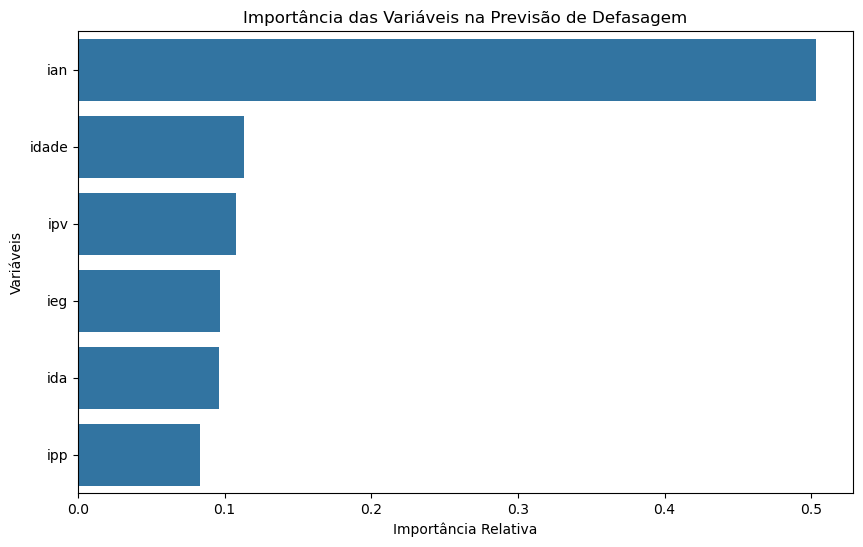

In [134]:
#Visualização da Importância das Variáveis no RandomForestClassifier
feature_importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title('Importância das Variáveis na Previsão de Defasagem')
plt.xlabel('Importância Relativa')
plt.ylabel('Variáveis')
plt.show()

In [135]:
import joblib
#Criando joblib da predição
#joblib.dump(model,'RandomForest.joblib')